In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import keras
import cv2
import pickle
import sklearn
import pydicom
import random

from sklearn.metrics import auc, f1_score, roc_curve, recall_score, precision_score, accuracy_score, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split
#from google.colab import files
from keras.preprocessing import image
from keras.layers import Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import *
from keras.layers import Dense, GlobalAveragePooling2D, Flatten
from keras.models import Model
from keras import backend as K
from tensorflow.keras import layers, Model
from keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img

I0000 00:00:1780928224.888798    1802 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780928225.047817    1802 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780928256.188296    1802 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


#**Data directory**

In [2]:
#test train split
###### todo: once xgboost is finished, make sure to copy the exact test/train split from there #######

path_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/deeplearning_path.csv'))
clinical_df = pd.read_csv(os.path.expanduser('~/project/xAI-in-NSCLC/NSCLC-Radiomics-Lung1.clinical-version3-Oct-2019.csv'))
path_to_save = os.path.expanduser('~/project/xAI-in-NSCLC')


#Testing code with first 40 images only.

patients = clinical_df.PatientID.unique()[: 40]

path_df = path_df.loc[path_df.PatientID.isin(patients)]
clinical_df = clinical_df.loc[clinical_df.PatientID.isin(patients)]


# test train split by patient ID
temp_df = clinical_df.dropna(subset=['Histology'])
X = temp_df['PatientID']
y = temp_df['Histology']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=204, stratify=y)

# save patient IDs for deep learning test train split later
train_labels = X_train.unique()
test_labels = X_test.unique()


# create test train split dfs for training
X_train = path_df.loc[path_df['PatientID'].isin(train_labels)]
y_train = X_train['Histology']
X_test = path_df.loc[path_df['PatientID'].isin(test_labels)]
y_test = X_test['Histology']

X_train = X_train.drop(columns=['PatientID', 'Histology'])
X_test = X_test.drop(columns=['PatientID', 'Histology'])


In [3]:
# base_dir = '/content/drive/MyDrive/PET-CTDICOMWholeDataset'

# training_set_dir = os.path.join(base_dir, 'trainingSet')
# test_set_dir = os.path.join(base_dir, 'testSet')

# train_lungCancer_dir = os.path.join(training_set_dir, 'lungCancer')
# train_normal_dir = os.path.join(training_set_dir, 'normal')
# test_lungCancer_dir = os.path.join(test_set_dir, 'lungCancer')
# test_normal_dir = os.path.join(test_set_dir, 'normal')

In [4]:
# mapping mapping = {'adenocarcinoma': 0, 'squamous cell carcinoma': 1, 'large cell': 2, 'nos':3 }

print('TRAINING SET DISTRIBUTION: -------------------')
print(f'\nAdenocarcinoma: {len(y_train.loc[y_train == 0])} images ({(len(y_train.loc[y_train == 0])/len(y_train))*100:.1f}%)')
print(f'Squamous cell: {len(y_train.loc[y_train == 1])} images ({(len(y_train.loc[y_train == 1])/len(y_train))*100:.1f}%)')
print(f'Large cell: {len(y_train.loc[y_train == 2])} images ({(len(y_train.loc[y_train == 2])/len(y_train))*100:.1f}%)')
print(f'Not otherwise specified:: {len(y_train.loc[y_train == 3])} images ({(len(y_train.loc[y_train == 3])/len(y_train))*100:.1f}%)')

print('\nTESTING SET DISTRIBUTION: --------------------')
print(f'\nAdenocarcinoma: {len(y_test.loc[y_test == 0])} images ({(len(y_test.loc[y_test == 0])/len(y_test))*100:.1f}%)')
print(f'Squamous cell: {len(y_test.loc[y_test == 1])} images ({(len(y_test.loc[y_test == 1])/len(y_test))*100:.1f}%)')
print(f'Large cell: {len(y_test.loc[y_test == 2])} images ({(len(y_test.loc[y_test == 2])/len(y_test))*100:.1f}%)')
print(f'Not otherwise specified:: {len(y_test.loc[y_test == 3])} images ({(len(y_test.loc[y_test == 3])/len(y_train))*100:.1f}%)')

TRAINING SET DISTRIBUTION: -------------------

Adenocarcinoma: 96 images (18.0%)
Squamous cell: 251 images (47.0%)
Large cell: 157 images (29.4%)
Not otherwise specified:: 30 images (5.6%)

TESTING SET DISTRIBUTION: --------------------

Adenocarcinoma: 36 images (19.4%)
Squamous cell: 94 images (50.5%)
Large cell: 37 images (19.9%)
Not otherwise specified:: 19 images (3.6%)


In [5]:
#Converting to onehot encoding

y_train = tf.keras.ops.one_hot(
    y_train, 4, axis=-1, dtype=None, sparse=False
)
y_test = tf.keras.ops.one_hot(
    y_test, 4, axis=-1, dtype=None, sparse=False
)

E0000 00:00:1780928284.700695    1802 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


#**Checking patient overlap**

In [6]:
def check_data_leakage(directory1, directory2):
    filenames_dir1 = directory1.values
    filenames_dir2 = directory2.values

    common_filenames = [f for f in filenames_dir2 if f in filenames_dir1]

    if len(common_filenames) > 0:
        print("Data leakage detected!")
        print("Common image filenames between the directories:", common_filenames)
    else:
        print("No data leakage detected.")

In [7]:
check_data_leakage(X_train, X_test)

No data leakage detected.


##**Data generation**

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

def load_and_preprocess_dicom(dcm_path):
    dcm_data = pydicom.dcmread(dcm_path)
    image_data = dcm_data.pixel_array
    # images have dimensions 512 x 512
    # INput size of model should be 299 x 299, [80:392 ,90:422] would be 312 x 332
    # Note: it's like this vertical:[top, bottom], [? ?]
    cropped_image_data = image_data[106:405 ,107:406] #This is 299 x299

    # Could still be improved? Sometimes the image shows the table, sometimes is shifted largely left or right..
    return cropped_image_data

In [9]:
train_image_labels = X_train.loc[X_train['path'].str.endswith('.dcm'), 'path'].tolist()
train_images = np.array([load_and_preprocess_dicom(file)for file in train_image_labels])

test_image_labels = X_test.loc[X_test['path'].str.endswith('.dcm'), 'path'].tolist()
test_images = np.array([load_and_preprocess_dicom(file)for file in test_image_labels])

In [10]:
#Converting greyscale to rgb, InceptionV3 requires 3 channel input

print(f'Training set dimensions before: {train_images.shape}')
train_images = np.repeat(train_images[..., np.newaxis], 3, -1)
print(f'Training set dimensions after: {train_images.shape}')

print(f'\nTesting set dimensions before: {test_images.shape}')
test_images = np.repeat(test_images[..., np.newaxis], 3, -1)
print(f'Testing set dimensions after: {test_images.shape}')

Training set dimensions before: (534, 299, 299)
Training set dimensions after: (534, 299, 299, 3)

Testing set dimensions before: (186, 299, 299)
Testing set dimensions after: (186, 299, 299, 3)


In [11]:
# You simply need to do this before showing in matplotlib, to return to greyscale values.
train_images[250][:, :, 1].shape

(299, 299)

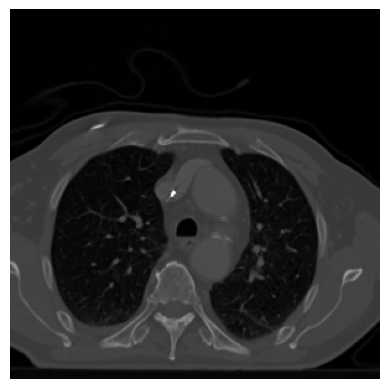

In [12]:
plt.imshow(train_images[250][:, :, 1], cmap='gray')
plt.axis('off')
plt.show()

In [13]:
# train_images = np.array([load_and_preprocess_dicom(os.path.join(train_lungCancer_dir, filename)) for filename in os.listdir(train_lungCancer_dir) if filename.endswith('.dcm')])
# train_images = np.array([load_and_preprocess_dicom()])
# train_labels = np.array([1] * len(train_images))

# normal_train_images = np.array([load_and_preprocess_dicom(os.path.join(train_normal_dir, filename)) for filename in os.listdir(train_normal_dir) if filename.endswith('.dcm')])
# normal_train_labels = np.array([0] * len(normal_train_images))

# train_images = np.concatenate((train_images, normal_train_images))
# train_labels = np.concatenate((train_labels, normal_train_labels))

train_generator = train_datagen.flow(train_images, y_train,
        batch_size=80,
        shuffle = True)

# test_images = np.array([load_and_preprocess_dicom(os.path.join(test_lungCancer_dir, filename)) for filename in os.listdir(test_lungCancer_dir) if filename.endswith('.dcm')])
# test_labels = np.array([1] * len(test_images))

# normal_test_images = np.array([load_and_preprocess_dicom(os.path.join(test_normal_dir, filename)) for filename in os.listdir(test_normal_dir) if filename.endswith('.dcm')])
# normal_test_labels = np.array([0] * len(normal_test_images))

# test_images = np.concatenate((test_images, normal_test_images))
# test_labels = np.concatenate((test_labels, normal_test_labels))

In [14]:
print(test_images[100].shape)
print(train_images[100].shape)

(299, 299, 3)
(299, 299, 3)


#**Defining InceptionV3 model**

In [15]:
pre_trained_model1 = InceptionV3(include_top=False,
                                        weights= 'imagenet',
                                        input_shape = (299, 299, 3)) #Could I specify input size here?

for layer in pre_trained_model1.layers:
  layer.trainable = False

In [21]:
#pre_trained_model1.summary()

In [17]:
last_layer1 = pre_trained_model1.get_layer('mixed10')
print(f'last layer output shape: {last_layer1.output.shape}')
last_output1 = last_layer1.output

x = layers.Flatten()(last_output1)
x = layers.Dense(2048, activation='relu')(x)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(4, activation='softmax')(x)

model1 = Model(pre_trained_model1.input, x)

last layer output shape: (None, 8, 8, 2048)


In [18]:
#layers.Dense(4, activation='softmax'))

In [19]:
#model1.summary()

In [26]:
savingPath = os.makedirs(os.path.expanduser('~/project/xAI-in-NSCLC/deep-learning results/temporaryWeights.weights.h5'))
checkpoint_path = os.path.expanduser('~/project/xAI-in-NSCLC/deep-learning results/Checkpoint_temporaryWeights.weights.h5')
checkpoint_dir = os.path.dirname(checkpoint_path)
print(checkpoint_path)
cp_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, save_weights_only=True, save_best_only=True, verbose= 1)

/home/coder/project/xAI-in-NSCLC/deep-learning results/Checkpoint_temporaryWeights.weights.h5


In [23]:
model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate= 0.001), loss='categorical_crossentropy', metrics=[tf.keras.metrics.CategoricalAccuracy(name='categorical_accuracy'),
                        tf.keras.metrics.Precision(name='Precision'),
                        tf.keras.metrics.Recall(name='Recall'),
                        tf.keras.metrics.TruePositives(name='TP'),
                        tf.keras.metrics.TrueNegatives(name='TN'),
                        tf.keras.metrics.FalseNegatives(name='FN'),
                        tf.keras.metrics.FalsePositives(name='FP'),
                        tf.keras.metrics.AUC(name='AUC')])

In [ ]:
history = model1.fit(train_generator, epochs=20, validation_data=(test_images, y_test),
            verbose = 2,
            callbacks = [cp_callback])

Epoch 1/20

Epoch 1: val_loss improved from None to 4465.09082, saving model to /home/coder/project/xAI-in-NSCLC/deep-learning results/Checkpoint_temporaryWeights.weights.h5
7/7 - 47s - 7s/step - AUC: 0.5893 - FN: 327.0000 - FP: 327.0000 - Precision: 0.3876 - Recall: 0.3876 - TN: 1275.0000 - TP: 207.0000 - categorical_accuracy: 0.3876 - loss: 13.3606 - val_AUC: 0.4014 - val_FN: 167.0000 - val_FP: 167.0000 - val_Precision: 0.1022 - val_Recall: 0.1022 - val_TN: 391.0000 - val_TP: 19.0000 - val_categorical_accuracy: 0.1022 - val_loss: 4465.0908
Epoch 2/20

Epoch 2: val_loss improved from 4465.09082 to 1077.36426, saving model to /home/coder/project/xAI-in-NSCLC/deep-learning results/Checkpoint_temporaryWeights.weights.h5
7/7 - 47s - 7s/step - AUC: 0.5563 - FN: 366.0000 - FP: 366.0000 - Precision: 0.3146 - Recall: 0.3146 - TN: 1236.0000 - TP: 168.0000 - categorical_accuracy: 0.3146 - loss: 7.5420 - val_AUC: 0.6703 - val_FN: 92.0000 - val_FP: 92.0000 - val_Precision: 0.5054 - val_Recall: 0.

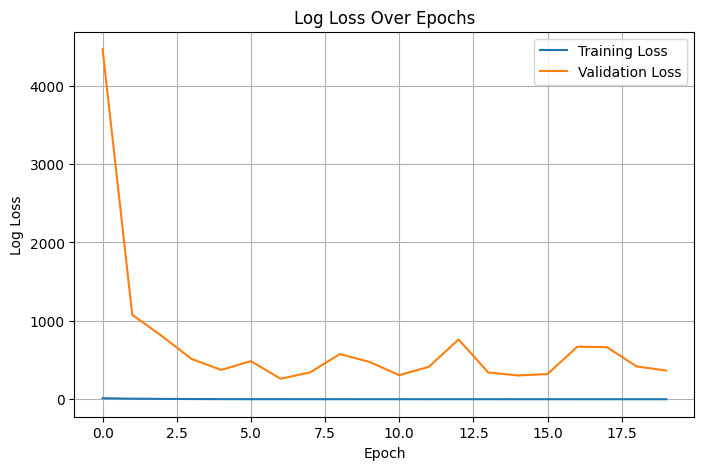

In [ ]:
# Extract loss values

# yeahhh I'm not sure whether this iwll imporve that much... Maybe subsample only a few patients per sample for the full dataset? Like 4 slices?
loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot
plt.figure(figsize=(8,5))
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Log Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()